# GNG and 2D cluster visualization 
## with in-code parameter setting
### Todo: Documentation

In [1]:
import gng_py
import numpy as np
import pandas as pd
import time
import json

In [2]:
from sklearn.datasets import make_blobs, make_circles


n_samples=300
noise=0.05
factor=0.3
random_state=1321


in_set, target = make_circles(
        n_samples=n_samples,
        noise=noise,
        factor=factor,
        random_state=random_state
    )

In [3]:

from sklearn.datasets import make_blobs

n_samples=1000
centers=2
cluster_std=0.5
random_state=321


in_set, target = make_blobs(
        n_samples=n_samples,
        centers=centers,
        cluster_std=cluster_std,
        random_state=random_state
    )

In [4]:
ctx = gng_py.PyContext()
ctx.create_system()


ctx.set_parameters(
            input_width = 2,
            weight_rng_min = -1.1,
            weight_rng_max = 1.1,
            edge_removal_age = 50,
            neuron_creation_interval = 200,
            max_train_iterations = 20000,
            target_error = 0.096,
            epsilon_w = 0.1,
            epsilon_n = 0.006,
            alpha = 0.5,
            beta = 0.995,
)






In [5]:
ctx.init_dataset_vec(in_set.flatten())
start = time.time()
ctx.fit()
end = time.time()
model_string = ctx.get_model_string()
print(end-start)

0.6072542667388916


In [6]:
data = json.loads(model_string)

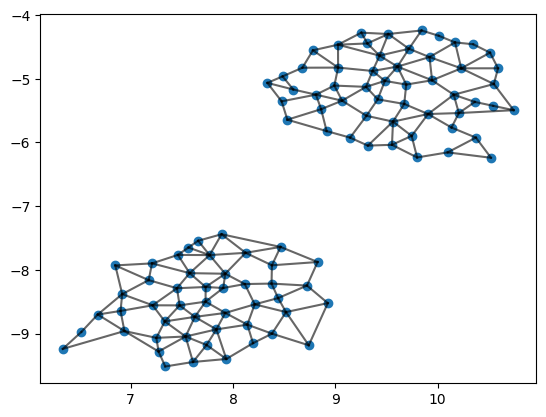

In [7]:
points = None
edges = None
edge_positions = None
rows = []
for neuron in data["model"]["neurons"]:
    position = neuron["position"]
    id = neuron['id']
    x = position[0]
    y = position[1]
    rows.append({"id": id, "x": x, "y": y})

points = pd.DataFrame(rows)

# Extract edges
row_edge = []
for edge in data['model']['edges']:
    edge_from = edge['from']
    edge_to = edge['to']
    row_edge.append({"start": edge_from, "to": edge_to})

edges = pd.DataFrame(row_edge)

# Calculate edge positions
row = []
for _, row_edge in edges.iterrows():
    try:
        row_from = points.loc[points['id'] == row_edge['start']].iloc[0]
        x_from = float(row_from['x'])
        y_from = float(row_from['y'])
        row_to = points.loc[points['id'] == row_edge['to']].iloc[0]
        x_to = float(row_to['x'])
        y_to = float(row_to['y'])

        row.append({"x_from": x_from, "y_from": y_from, "x_to": x_to, "y_to": y_to})
    except (IndexError, KeyError):
        continue

edge_positions = pd.DataFrame(row)
import matplotlib.pyplot as plt
plot = plt.figure()
ax = plot.add_subplot(111)

ax.clear()

# Plot points
ax.scatter(points['x'], points['y'])

# Plot connections
for _, row in edges.iterrows():
    row_from = points.loc[points['id'] == row['start']].iloc[0]
    x_from = float(row_from['x'])
    y_from = float(row_from['y'])
    row_to = points.loc[points['id'] == row['to']].iloc[0]
    x_to = float(row_to['x'])
    y_to = float(row_to['y'])

    ax.plot([x_from, x_to], [y_from, y_to], 'k-', alpha=0.6)


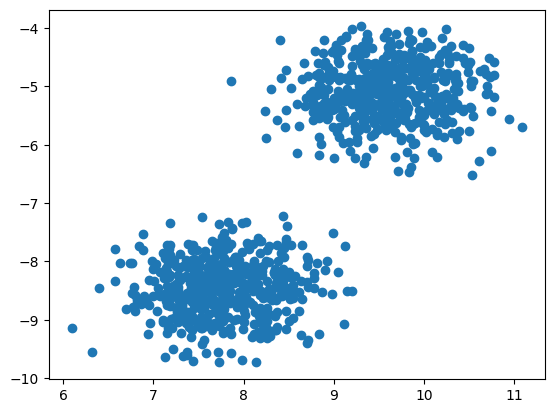

In [8]:
plot = plt.scatter(in_set[:,0],in_set[:,1])
